# Final Project — RAG_LLM Workload Analysis

**Milestone 3: Propose and evaluate optimization(s).**
1. Implement an optimization to speed up RAG (e.g., keeping some documents in DRAM).
2. Analyze the trade-offs associated with this optimization.
3. Compare the energy and latency to the baseline method.
4. Analyze the mappings and energy breakdown, and report the source of energy and/or latency improvements.

## Step 1: Imports

In [1]:
import sys
import os

# Make _load_spec.py and scripts/ importable from the workspace root
WORKSPACE_DIR = os.path.dirname(os.path.abspath('.'))
sys.path.insert(0, '/home/workspace/workspace')
sys.path.insert(0, '/home/workspace/workspace/scripts')

import accelforge as af
from _load_spec import get_spec
from utils import Result, round_rank_sizes
from plots import bar_side_by_side, bar_stacked, plot
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import pandas as pd
%matplotlib inline

## Step 2: Define Parameters

Edit these dicts to change the RAG_LLM workload size or the architecture configuration.

In [2]:
# RAG_LLM Jinja parameters (passed to workload/RAG_LLM.yaml)
rag_params = {
    'N_DOCS':     5_000_000,   # number of documents in corpus, EdgeRAG range from 3k to 5M
    'N_TOKENS':   512,    # query token length
    'K':     10,     # top-k documents retrieved
    'L': 512 # length of each document
}

# basic8 Jinja parameters (passed to arch/basic8.yaml)
arch_overrides = {
    'DRAM_SIZE_GB':       8,     # off-chip DRAM capacity in GB
    'DRAM_BW_GBps':       68,    # LPDDR5 bandwidth in GB/s
    'SRAM_SIZE_MB':       8,     # on-chip SRAM capacity in MB
    'SRAM_READ_BW_GBps':  512,   # SRAM read bandwidth in GB/s
    'SRAM_WRITE_BW_GBps': 128,   # SRAM write bandwidth in GB/s
    'MAC_ENERGY_pJ':      0.084, # FP16 MAC energy in pJ
    'MAC_CLOCK_GHz':      1,     # clock frequency in GHz
}

print('RAG_LLM params:', rag_params)
print('Arch overrides:', arch_overrides)

RAG_LLM params: {'N_DOCS': 5000000, 'N_TOKENS': 512, 'K': 10, 'L': 512}
Arch overrides: {'DRAM_SIZE_GB': 8, 'DRAM_BW_GBps': 68, 'SRAM_SIZE_MB': 8, 'SRAM_READ_BW_GBps': 512, 'SRAM_WRITE_BW_GBps': 128, 'MAC_ENERGY_pJ': 0.084, 'MAC_CLOCK_GHz': 1}


## Step 3: Load the RAG_LLM Workload

In [3]:
WORKLOAD_PATH = '/home/workspace/workspace/workload/full_EdgeRAG.yaml'

workload = af.Workload.from_yaml(
    WORKLOAD_PATH,
    top_key='workload',
    jinja_parse_data={},
)
# renames = af.Renames.from_yaml(
#     WORKLOAD_PATH,
#     top_key='renames',
#     jinja_parse_data=rag_params,
# )
# per einsum sparisty --> TODO just multiply
print(f'Loaded {len(workload.einsums)} einsums:')
for e in workload.einsums:
    print(f'  {e.name}')

Loaded 28 einsums:
  enc_input
  enc_queries
  enc_keys
  enc_values
  enc_attn_scores
  enc_attn_weights
  enc_attn_out
  enc_attn_proj
  enc_ffn_hidden
  enc_ffn_hidden_act
  enc_ffn_out
  query_embedding
  doc_scores
  topk_doc_ids
  topk_tokens
  dec_input
  dec_queries
  dec_keys
  dec_values
  dec_attn_scores
  dec_attn_weights
  dec_attn_out
  dec_attn_proj
  dec_ffn_gate
  dec_ffn_up
  dec_ffn_gate_act
  dec_ffn_swiglu
  dec_ffn_out


## Step 4: Run Each Einsum Through the Architecture

Copy operations (`is_copy_operation: True`) will have zero compute energy â€” that is expected.

In [4]:
print(workload.rank_sizes)

{'BATCH': 1, 'NUM_DOCS': 2000000, 'TOP_K_DOCS': 10, 'DOC_LEN': 512, 'ENC_SEQ_LEN': 512, 'ENC_KV_POS': 512, 'ENC_NUM_HEADS': 12, 'ENC_HEAD_DIM': 64, 'ENC_HIDDEN': 768, 'ENC_FFN_MID': 3072, 'ENC_EMBED_DIM': 768, 'DEC_SEQ_LEN': 5632, 'DEC_KV_POS': 5632, 'DEC_NUM_HEADS': 20, 'DEC_HEAD_DIM': 128, 'DEC_HIDDEN': 2560, 'DEC_FFN_MID': 6912, 'DEC_VOCAB': 32000}


In [5]:
results = {}

for einsum in workload.einsums:
    print(f'Running {einsum.name}...')
    # basic8 already includes Disk, MainMemory, OnChipSRAM — no dummy memory needed
    spec = get_spec('basic8', add_dummy_main_memory=False, jinja_parse_data=arch_overrides)

    spec.workload = af.Workload(
        einsums=[einsum],
        rank_sizes=workload.rank_sizes,
        bits_per_value=workload.bits_per_value,
        persistent_tensors=workload.persistent_tensors,
    )
    
    # spec.renames = renames
    spec.mapper.max_pmapping_templates_per_einsum = 1
    # round_rank_sizes(spec.workload)
    spec.mapper.metrics = af.mapper.Metrics.ENERGY | af.mapper.Metrics.LATENCY

    mappings = spec.map_workload_to_arch(print_progress=False, print_number_of_pmappings=False)
    results[einsum.name] = Result(mappings, variables=rag_params)
    print(f'  done — {results[einsum.name].per_compute("energy")*1e12:.2f} pJ/compute')
    print(f'Latency: {mappings.latency()}s, {mappings.per_compute().latency()}s/compute')
    for k, v in mappings.per_compute().latency(per_component=True).items():
        print(f'\t{k}: {v}s/compute')


print('All einsums complete.')

Running enc_input...
  done — 0.00 pJ/compute
Latency: 0.00039321600343100727s, 9.999999717180685e-10s/compute
	Disk: 0.0s/compute
	Copy: 9.999999717180685e-10s/compute
Running enc_queries...
  done — 8.92 pJ/compute
Latency: 0.301989883184433s, 9.999999717180685e-10s/compute
	MAC: 9.999999717180685e-10s/compute
	OnChipSRAM: 7.837931692566968e-12s/compute
	MainMemory: 1.3403799012552675e-13s/compute
	Disk: 6.510416663239871e-13s/compute
Running enc_keys...
  done — 8.92 pJ/compute
Latency: 0.301989883184433s, 9.999999717180685e-10s/compute
	MAC: 9.999999717180685e-10s/compute
	OnChipSRAM: 7.837931692566968e-12s/compute
	MainMemory: 1.3403799012552675e-13s/compute
	Disk: 6.510416663239871e-13s/compute
Running enc_values...
  done — 8.92 pJ/compute
Latency: 0.301989883184433s, 9.999999717180685e-10s/compute
	MAC: 9.999999717180685e-10s/compute
	OnChipSRAM: 7.837931692566968e-12s/compute
	MainMemory: 1.3403799012552675e-13s/compute
	Disk: 6.510416663239871e-13s/compute
Running enc_attn_sc

Running enc_input...
Latency: 0.00039321600343100727s, 9.999999717180685e-10s/compute
Running enc_queries...
Latency: 0.301989883184433s, 9.999999717180685e-10s/compute
Running enc_keys...
Latency: 0.301989883184433s, 9.999999717180685e-10s/compute
Running enc_values...
Latency: 0.301989883184433s, 9.999999717180685e-10s/compute
Running enc_attn_scores...
Latency: 0.20132659375667572s, 9.999999717180685e-10s/compute
Running enc_attn_weights...
Latency: 0.003145728027448058s, 9.999999717180685e-10s/compute
Running enc_attn_out...
Latency: 0.20132659375667572s, 9.999999717180685e-10s/compute
Running enc_attn_proj...
Latency: 0.301989883184433s, 9.999999717180685e-10s/compute
Running enc_ffn_hidden...
Latency: 1.207959532737732s, 9.999999717180685e-10s/compute
Running enc_ffn_hidden_act...
Latency: 0.001572864013724029s, 9.999999717180685e-10s/compute
Running enc_ffn_out...
Latency: 1.207959532737732s, 9.999999717180685e-10s/compute
Running query_embedding...
Latency: 0.000393216003431007

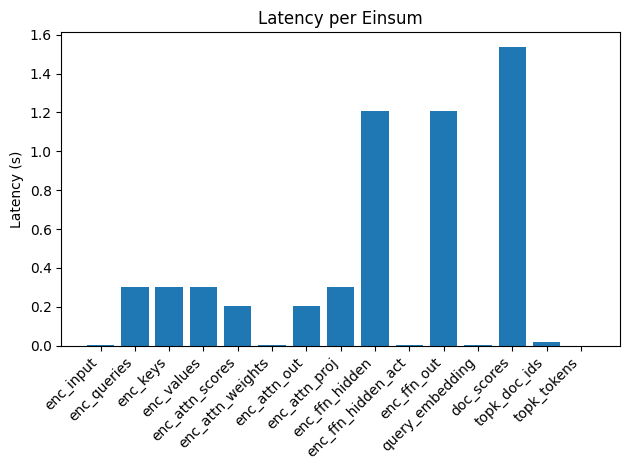

In [6]:
import matplotlib.pyplot as plt

einsum_names = []
latencies = []
per_compute_latencies = []

count = 0

for einsum in workload.einsums:
    count += 1
    print(f'Running {einsum.name}...')
    spec = get_spec('basic8', add_dummy_main_memory=False, jinja_parse_data=arch_overrides)

    spec.workload = af.Workload(
        einsums=[einsum],
        rank_sizes=workload.rank_sizes,
        bits_per_value=workload.bits_per_value,
        persistent_tensors=workload.persistent_tensors,
    )

    spec.mapper.max_pmapping_templates_per_einsum = 1
    round_rank_sizes(spec.workload)
    spec.mapper.metrics = af.mapper.Metrics.ENERGY | af.mapper.Metrics.LATENCY

    mappings = spec.map_workload_to_arch(
        print_progress=False,
        print_number_of_pmappings=False
    )

    # ---- store results ----
    if count <= 15: # only examine the RAG
        einsum_names.append(einsum.name)
        latencies.append(mappings.latency())
        per_compute_latencies.append(mappings.per_compute().latency())

    print(f'Latency: {mappings.latency()}s, {mappings.per_compute().latency()}s/compute')

plt.figure()
plt.bar(einsum_names, latencies)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Latency (s)")
plt.title("Latency per Einsum")
plt.tight_layout()
plt.show()

Running enc_input...
Latency: 0.00039321600343100727s, 9.999999717180685e-10s/compute
Running enc_queries...
Latency: 0.301989883184433s, 9.999999717180685e-10s/compute
Running enc_keys...
Latency: 0.301989883184433s, 9.999999717180685e-10s/compute
Running enc_values...
Latency: 0.301989883184433s, 9.999999717180685e-10s/compute
Running enc_attn_scores...
Latency: 0.20132659375667572s, 9.999999717180685e-10s/compute
Running enc_attn_weights...
Latency: 0.003145728027448058s, 9.999999717180685e-10s/compute
Running enc_attn_out...
Latency: 0.20132659375667572s, 9.999999717180685e-10s/compute
Running enc_attn_proj...
Latency: 0.301989883184433s, 9.999999717180685e-10s/compute
Running enc_ffn_hidden...
Latency: 1.207959532737732s, 9.999999717180685e-10s/compute
Running enc_ffn_hidden_act...
Latency: 0.001572864013724029s, 9.999999717180685e-10s/compute
Running enc_ffn_out...
Latency: 1.207959532737732s, 9.999999717180685e-10s/compute
Running query_embedding...
Latency: 0.000393216003431007

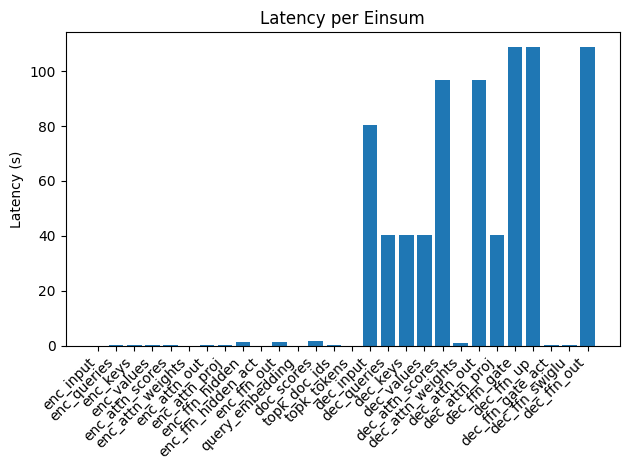

In [7]:

einsum_names = []
latencies = []
per_compute_latencies = []

for einsum in workload.einsums:

    print(f'Running {einsum.name}...')

    spec = get_spec('basic8', add_dummy_main_memory=False, jinja_parse_data=arch_overrides)

    spec.workload = af.Workload(
        einsums=[einsum],
        rank_sizes=workload.rank_sizes,
        bits_per_value=workload.bits_per_value,
        persistent_tensors=workload.persistent_tensors,
    )

    spec.mapper.max_pmapping_templates_per_einsum = 1
    round_rank_sizes(spec.workload)
    spec.mapper.metrics = af.mapper.Metrics.ENERGY | af.mapper.Metrics.LATENCY

    mappings = spec.map_workload_to_arch(
        print_progress=False,
        print_number_of_pmappings=False
    )
    svg_string = mappings.render() # svg
    # if einsum.name == "TK":
    #     print(svg_string)

    # ---- store results ----
    einsum_names.append(einsum.name)
    latencies.append(mappings.latency())
    per_compute_latencies.append(mappings.per_compute().latency())

    print(f'Latency: {latencies[-1]}s, {per_compute_latencies[-1]}s/compute')

plt.figure()
plt.bar(einsum_names, latencies)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Latency (s)")
plt.title("Latency per Einsum")
plt.tight_layout()
plt.show()

In [8]:
mappings # print mappings per einsum, currently only printing the last one
print("pass")

pass


## Step 5: Inspect Results

In [9]:
print(f'{"Einsum":<30} {"pJ/compute":>12}  Per-component energy (fJ/compute)')
print('-' * 80)
for name, result in results.items():
    result.clear_zero_energies()
    pj = result.per_compute('energy') * 1e12
    components = {k: f'{v*1e15:.2f}fJ' for k, v in result.per_compute('per_component_energy').items()}
    print(f'{name:<30} {pj:>12.2f}  {components}')

Einsum                           pJ/compute  Per-component energy (fJ/compute)
--------------------------------------------------------------------------------
enc_input                              0.00  {}
enc_queries                            8.92  {'OnChipSRAM': '8327.63fJ', 'MainMemory': '512.60fJ', 'MAC': '84.00fJ'}
enc_keys                               8.92  {'OnChipSRAM': '8327.63fJ', 'MainMemory': '512.60fJ', 'MAC': '84.00fJ'}
enc_values                             8.92  {'OnChipSRAM': '8327.63fJ', 'MainMemory': '512.60fJ', 'MAC': '84.00fJ'}
enc_attn_scores                       10.61  {'OnChipSRAM': '8329.16fJ', 'MainMemory': '2196.87fJ', 'MAC': '84.00fJ'}
enc_attn_weights                     233.63  {'OnChipSRAM': '8672.00fJ', 'MainMemory': '224960.00fJ'}
enc_attn_out                          10.64  {'OnChipSRAM': '8361.20fJ', 'MainMemory': '2196.87fJ', 'MAC': '84.00fJ'}
enc_attn_proj                          8.92  {'OnChipSRAM': '8327.63fJ', 'MainMemory': '512.60fJ', 'MAC

## Step 6: Plot Per-Einsum Energy Breakdown

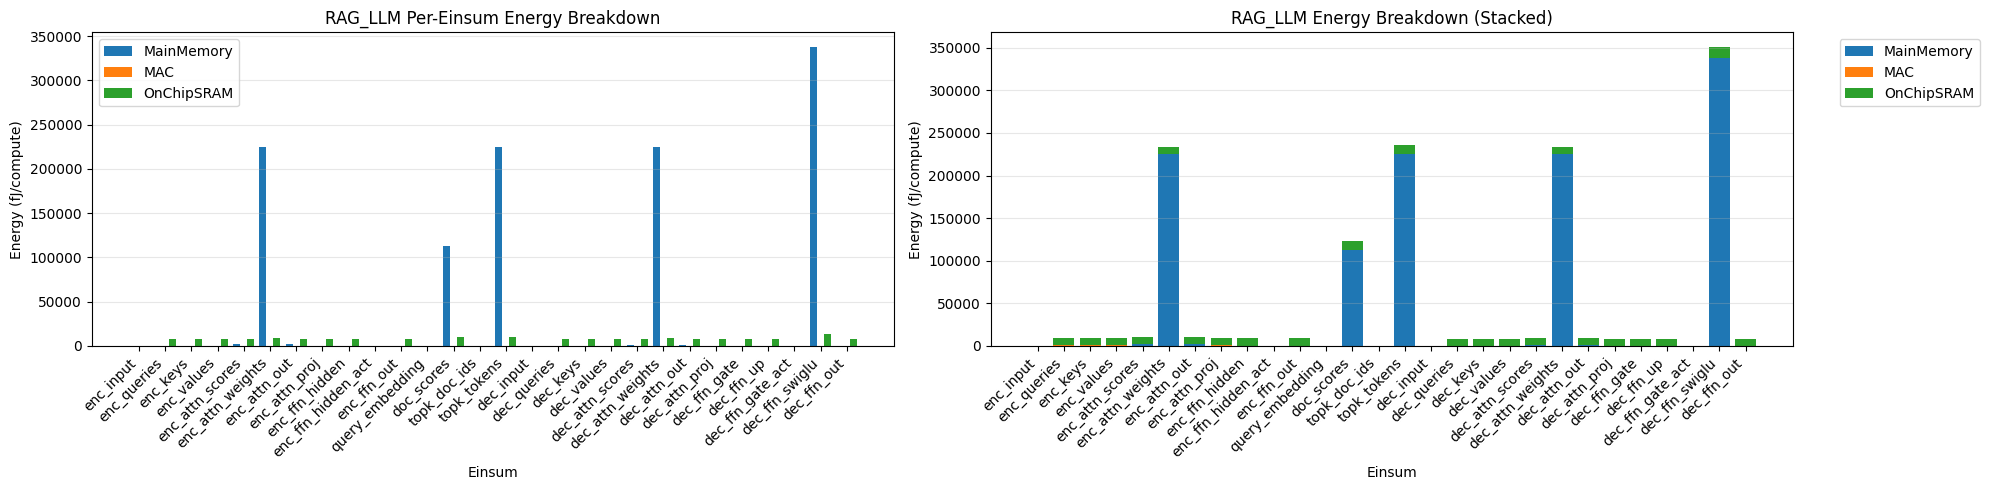

In [10]:
plot_data = {}
for name, result in results.items():
    result.clear_zero_energies()
    plot_data[name] = {k: v * 1e15 for k, v in result.per_compute('per_component_energy').items()}

fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# Side-by-side bar chart
bar_side_by_side(
    plot_data,
    title='RAG_LLM Per-Einsum Energy Breakdown',
    xlabel='Einsum',
    ylabel='Energy (fJ/compute)',
    ax=axes[0]
)

# Stacked bar chart for better comparison
bar_stacked(
    plot_data,
    title='RAG_LLM Energy Breakdown (Stacked)',
    xlabel='Einsum',
    ylabel='Energy (fJ/compute)',
    ax=axes[1]
)
plt.tight_layout()
plt.show()  # TODO softmax should be fused

## Step 7: Analysis Helper Functions

These functions encapsulate the mapping logic so we can run parameter sweeps efficiently.

In [11]:
def run_rag_workload(rag_params, arch_overrides, einsum_names=None):
    """
    Run the RAG workload with given parameters, returning results for each einsum.

    Parameters
    ----------
    rag_params : dict
        Workload parameters (N_DOCS, N_TOKENS, K, L)
    arch_overrides : dict
        Architecture parameters (DRAM_SIZE_GB, SRAM_SIZE_MB, etc.)
    einsum_names : list, optional
        Which einsums to run. If None, runs all.

    Returns
    -------
    dict[str, Result]
        Results keyed by einsum name
    """
    workload = af.Workload.from_yaml(
        WORKLOAD_PATH,
        top_key='workload',
        jinja_parse_data=rag_params,
    )
    # renames = af.Renames.from_yaml(
    #     WORKLOAD_PATH,
    #     top_key='renames',
    #     jinja_parse_data=rag_params,
    # )

    results = {}
    for einsum in workload.einsums:
        if einsum_names is not None and einsum.name not in einsum_names:
            continue

        spec = get_spec('basic8', add_dummy_main_memory=False, jinja_parse_data=arch_overrides)
        spec.workload = af.Workload(
            einsums=[einsum],
            rank_sizes=workload.rank_sizes,
            bits_per_value=workload.bits_per_value,
            persistent_tensors=workload.persistent_tensors,
        )
        # spec.renames = renames
        spec.mapper.max_pmapping_templates_per_einsum = 1
        round_rank_sizes(spec.workload)
        spec.mapper.metrics = af.mapper.Metrics.ENERGY

        mappings = spec.map_workload_to_arch(print_progress=False, print_number_of_pmappings=False)
        results[einsum.name] = Result(mappings, variables=rag_params)

    return results


def aggregate_results(results):
    """
    Aggregate per-einsum results into total energy and per-component breakdown.

    Returns
    -------
    dict with keys:
        'total_energy_J': float
        'total_computes': int
        'per_component_energy_J': dict[str, float]
        'per_einsum_energy_J': dict[str, float]
        'per_einsum_computes': dict[str, int]
    """
    total_energy = 0
    total_computes = 0
    per_component = defaultdict(float)
    per_einsum_energy = {}
    per_einsum_computes = {}

    for name, result in results.items():
        result.clear_zero_energies()
        einsum_energy = sum(result.per_component_energy.values())
        einsum_computes = result.computes

        total_energy += einsum_energy
        total_computes += einsum_computes
        per_einsum_energy[name] = einsum_energy
        per_einsum_computes[name] = einsum_computes

        for comp, energy in result.per_component_energy.items():
            per_component[comp] += energy

    return {
        'total_energy_J': total_energy,
        'total_computes': total_computes,
        'per_component_energy_J': dict(per_component),
        'per_einsum_energy_J': per_einsum_energy,
        'per_einsum_computes': per_einsum_computes,
    }


def get_latency_from_mappings(results):
    """
    Extract latency information from results.
    Note: This requires re-running with LATENCY metric or extracting from mappings.
    For now, we estimate based on bandwidth and data movement.
    """
    # AccelForge Result doesn't directly expose latency in the current wrapper
    # We'll compute estimated latency from energy and bandwidth assumptions
    pass

print("Helper functions defined.")

Helper functions defined.


## Step 8: Initial Bottleneck Analysis

Before sweeping parameters, let's understand what the baseline results tell us about bottlenecks.

In [12]:
# Analyze bottlenecks from the baseline run
print("=" * 80)
print("BOTTLENECK ANALYSIS: Baseline Configuration")
print(f"N_DOCS={rag_params['N_DOCS']}, N_TOKENS={rag_params['N_TOKENS']}, K={rag_params['K']}")
print("=" * 80)

# Aggregate results
agg = aggregate_results(results)

# 1. Which einsums dominate total energy?
print("\n1. EINSUM ENERGY BREAKDOWN (sorted by energy)")
print("-" * 60)
sorted_einsums = sorted(agg['per_einsum_energy_J'].items(), key=lambda x: x[1], reverse=True)
for name, energy in sorted_einsums:
    pct = 100 * energy / agg['total_energy_J'] if agg['total_energy_J'] > 0 else 0
    print(f"  {name:<12} {energy*1e9:>10.2f} nJ  ({pct:>5.1f}%)")

print(f"\n  TOTAL:      {agg['total_energy_J']*1e9:>10.2f} nJ")

# 2. Which architectural components dominate?
print("\n2. COMPONENT ENERGY BREAKDOWN (sorted by energy)")
print("-" * 60)
sorted_components = sorted(agg['per_component_energy_J'].items(), key=lambda x: x[1], reverse=True)
for comp, energy in sorted_components:
    pct = 100 * energy / agg['total_energy_J'] if agg['total_energy_J'] > 0 else 0
    print(f"  {comp:<15} {energy*1e9:>10.2f} nJ  ({pct:>5.1f}%)")

# 3. Identify the bottleneck
print("\n3. KEY INSIGHTS")
print("-" * 60)
top_einsum = sorted_einsums[0][0] if sorted_einsums else None
top_component = sorted_components[0][0] if sorted_components else None
print(f"  - Highest energy einsum: {top_einsum}")
print(f"  - Highest energy component: {top_component}")

# 4. Per-einsum component breakdown for top consumers
print("\n4. COMPONENT BREAKDOWN FOR TOP ENERGY CONSUMERS")
print("-" * 60)
for name, _ in sorted_einsums[:3]:  # Top 3
    result = results[name]
    result.clear_zero_energies()
    print(f"\n  {name}:")
    for comp, energy in sorted(result.per_component_energy.items(), key=lambda x: x[1], reverse=True):
        total_einsum = sum(result.per_component_energy.values())
        pct = 100 * energy / total_einsum if total_einsum > 0 else 0
        print(f"    {comp:<15} {energy*1e9:>8.2f} nJ  ({pct:>5.1f}%)")

BOTTLENECK ANALYSIS: Baseline Configuration
N_DOCS=5000000, N_TOKENS=512, K=10

1. EINSUM ENERGY BREAKDOWN (sorted by energy)
------------------------------------------------------------
  dec_ffn_out  849006508.79 nJ  ( 14.9%)
  dec_ffn_gate 847269884.00 nJ  ( 14.8%)
  dec_ffn_up   847269884.00 nJ  ( 14.8%)
  dec_attn_scores 758775656.11 nJ  ( 13.3%)
  dec_attn_out 758539537.77 nJ  ( 13.3%)
  dec_queries  314220354.51 nJ  (  5.5%)
  dec_keys     314220354.51 nJ  (  5.5%)
  dec_values   314220354.51 nJ  (  5.5%)
  dec_attn_proj 314220354.51 nJ  (  5.5%)
  doc_scores   189512201.86 nJ  (  3.3%)
  dec_attn_weights 148213443.61 nJ  (  2.6%)
  dec_ffn_swiglu 13645645.20 nJ  (  0.2%)
  enc_ffn_out  10647427.22 nJ  (  0.2%)
  enc_ffn_hidden 10644662.13 nJ  (  0.2%)
  enc_queries  2695028.52 nJ  (  0.0%)
  enc_keys     2695028.52 nJ  (  0.0%)
  enc_values   2695028.52 nJ  (  0.0%)
  enc_attn_proj 2695028.52 nJ  (  0.0%)
  enc_attn_out 2142533.31 nJ  (  0.0%)
  enc_attn_scores 2136081.39 nJ  (

## Step 9: Sweep Number of Documents (N_DOCS)

This experiment varies the RAG corpus size to understand how retrieval scales.

In [13]:
# Sweep N_DOCS: Number of documents in the RAG corpus
N_DOCS_VALUES = [3600, 7200, 1_000_000, 2_000_000, 5_000_000] # wide range for EdgeRAG

sweep_n_docs_results = {}

print("Sweeping N_DOCS...")
for n_docs in N_DOCS_VALUES:
    print(f"  N_DOCS = {n_docs}...", end=" ")

    params = {
        'N_DOCS': n_docs,
        'N_TOKENS': 512,
        'K': 10,
    }

    results_sweep = run_rag_workload(params, arch_overrides)
    sweep_n_docs_results[n_docs] = {
        'results': results_sweep,
        'aggregated': aggregate_results(results_sweep),
    }
    print(f"Total energy: {sweep_n_docs_results[n_docs]['aggregated']['total_energy_J']*1e9:.2f} nJ")

print("Done.")

Sweeping N_DOCS...
  N_DOCS = 3600... Total energy: 6179624991.42 nJ
  N_DOCS = 7200... Total energy: 6179966097.14 nJ
  N_DOCS = 1000000... Total energy: 6274039920.79 nJ
  N_DOCS = 2000000... Total energy: 6368795999.37 nJ
  N_DOCS = 5000000... Total energy: 6653064293.89 nJ
Done.


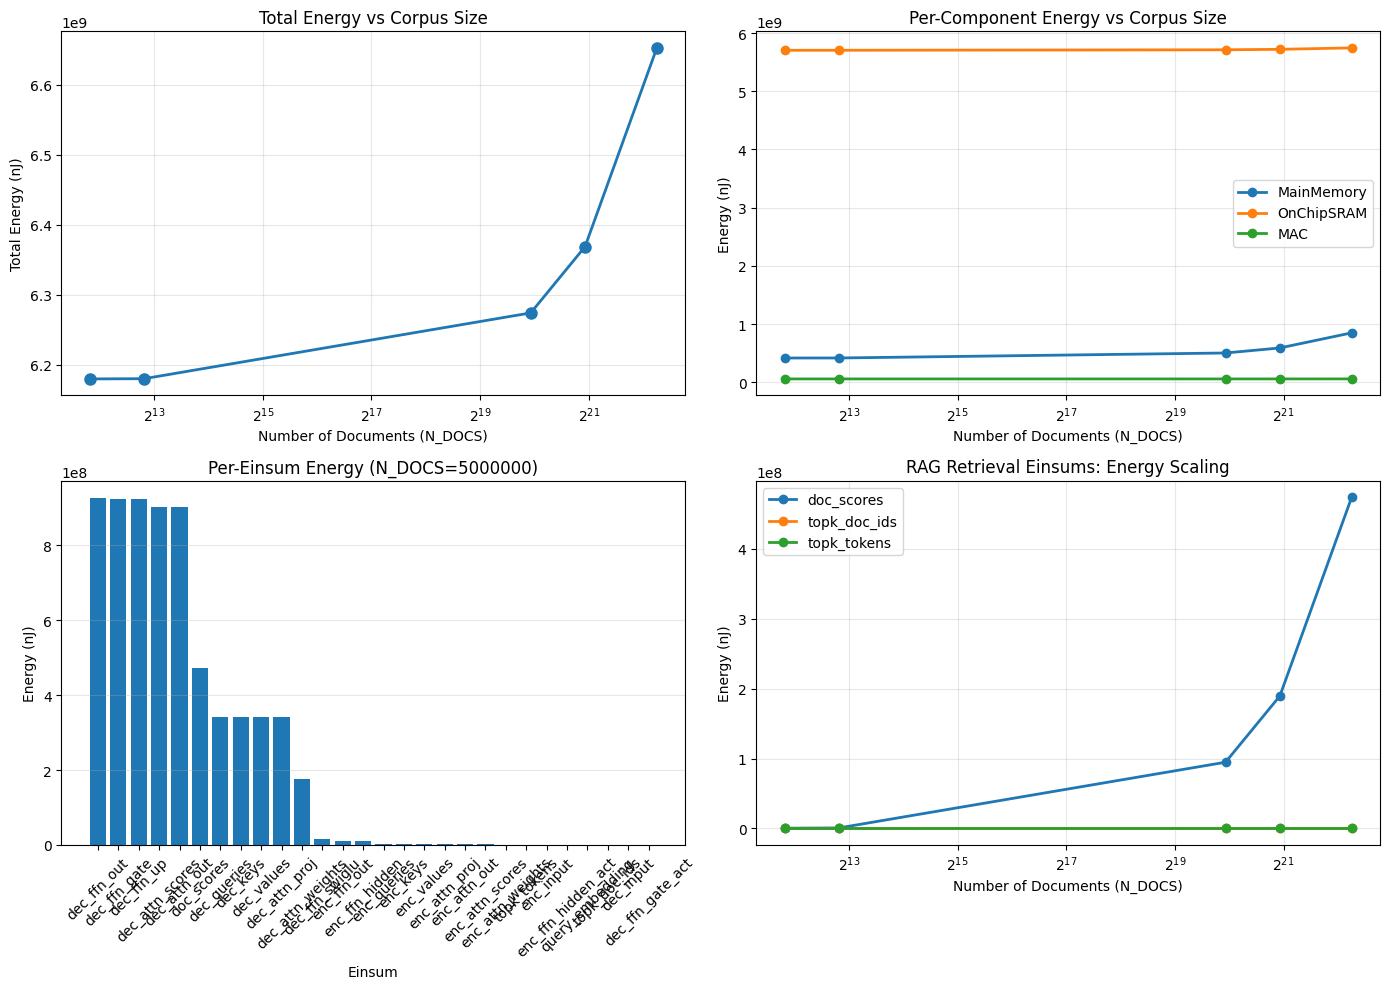

In [14]:
# Plot N_DOCS sweep results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Total energy vs N_DOCS
ax1 = axes[0, 0]
n_docs_list = list(sweep_n_docs_results.keys())
total_energies = [sweep_n_docs_results[n]['aggregated']['total_energy_J'] * 1e9 for n in n_docs_list]
ax1.plot(n_docs_list, total_energies, 'o-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Documents (N_DOCS)')
ax1.set_ylabel('Total Energy (nJ)')
ax1.set_title('Total Energy vs Corpus Size')
ax1.set_xscale('log', base=2)
ax1.grid(True, alpha=0.3)

# 2. Per-component energy vs N_DOCS
ax2 = axes[0, 1]
components = ['MainMemory', 'OnChipSRAM', 'MAC']
for comp in components:
    energies = [sweep_n_docs_results[n]['aggregated']['per_component_energy_J'].get(comp, 0) * 1e9
                for n in n_docs_list]
    ax2.plot(n_docs_list, energies, 'o-', label=comp, linewidth=2, markersize=6)
ax2.set_xlabel('Number of Documents (N_DOCS)')
ax2.set_ylabel('Energy (nJ)')
ax2.set_title('Per-Component Energy vs Corpus Size')
ax2.set_xscale('log', base=2)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Per-einsum energy for largest N_DOCS
ax3 = axes[1, 0]
largest_n = max(n_docs_list)
einsum_energies = sweep_n_docs_results[largest_n]['aggregated']['per_einsum_energy_J']
sorted_einsums = sorted(einsum_energies.items(), key=lambda x: x[1], reverse=True)
names = [e[0] for e in sorted_einsums]
energies = [e[1] * 1e9 for e in sorted_einsums]
bars = ax3.bar(names, energies)
ax3.set_xlabel('Einsum')
ax3.set_ylabel('Energy (nJ)')
ax3.set_title(f'Per-Einsum Energy (N_DOCS={largest_n})')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', alpha=0.3)

# 4. RAG-specific einsums
ax4 = axes[1, 1]
rag_einsums = ['doc_scores', 'topk_doc_ids', 'topk_tokens']
for einsum_name in rag_einsums:
    energies = [sweep_n_docs_results[n]['aggregated']['per_einsum_energy_J'].get(einsum_name, 0) * 1e9
                for n in n_docs_list]
    ax4.plot(n_docs_list, energies, 'o-', label=einsum_name, linewidth=2, markersize=6)
ax4.set_xlabel('Number of Documents (N_DOCS)')
ax4.set_ylabel('Energy (nJ)')
ax4.set_title('RAG Retrieval Einsums: Energy Scaling')
ax4.set_xscale('log', base=2)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show() # TODO explore 6.7B, look at graphs dont sum up...

## Step 10: Sweep Document Size (L)

This experiment varies the token length to understand how document size affects energy.
Change in variables: l is size of query, L is length of each document

In [15]:
L_VALUES = [128, 256, 512, 1024, 2048]

sweep_l_results = {}

print("Sweeping l...")
for l in L_VALUES:
    print(f"  L = {l}...", end=" ")

    params = {
        # 'VOCAB_SIZE': 32000,
        'N_DOCS': 3600,
        'L': l,
        'K': 10,
    }

    results_sweep = run_rag_workload(params, arch_overrides)
    sweep_l_results[l] = {
        'results': results_sweep,
        'aggregated': aggregate_results(results_sweep),
    }
    print(f"Total energy: {sweep_l_results[l]['aggregated']['total_energy_J']*1e9:.2f} nJ")

print("Done.")

Sweeping l...
  L = 128... Total energy: 1427080080.84 nJ
  L = 256... Total energy: 2619090774.16 nJ
  L = 512... Total energy: 6179624991.42 nJ
  L = 1024... Total energy: 13372881288.28 nJ
  L = 2048... Total energy: 38801933190.16 nJ
Done.


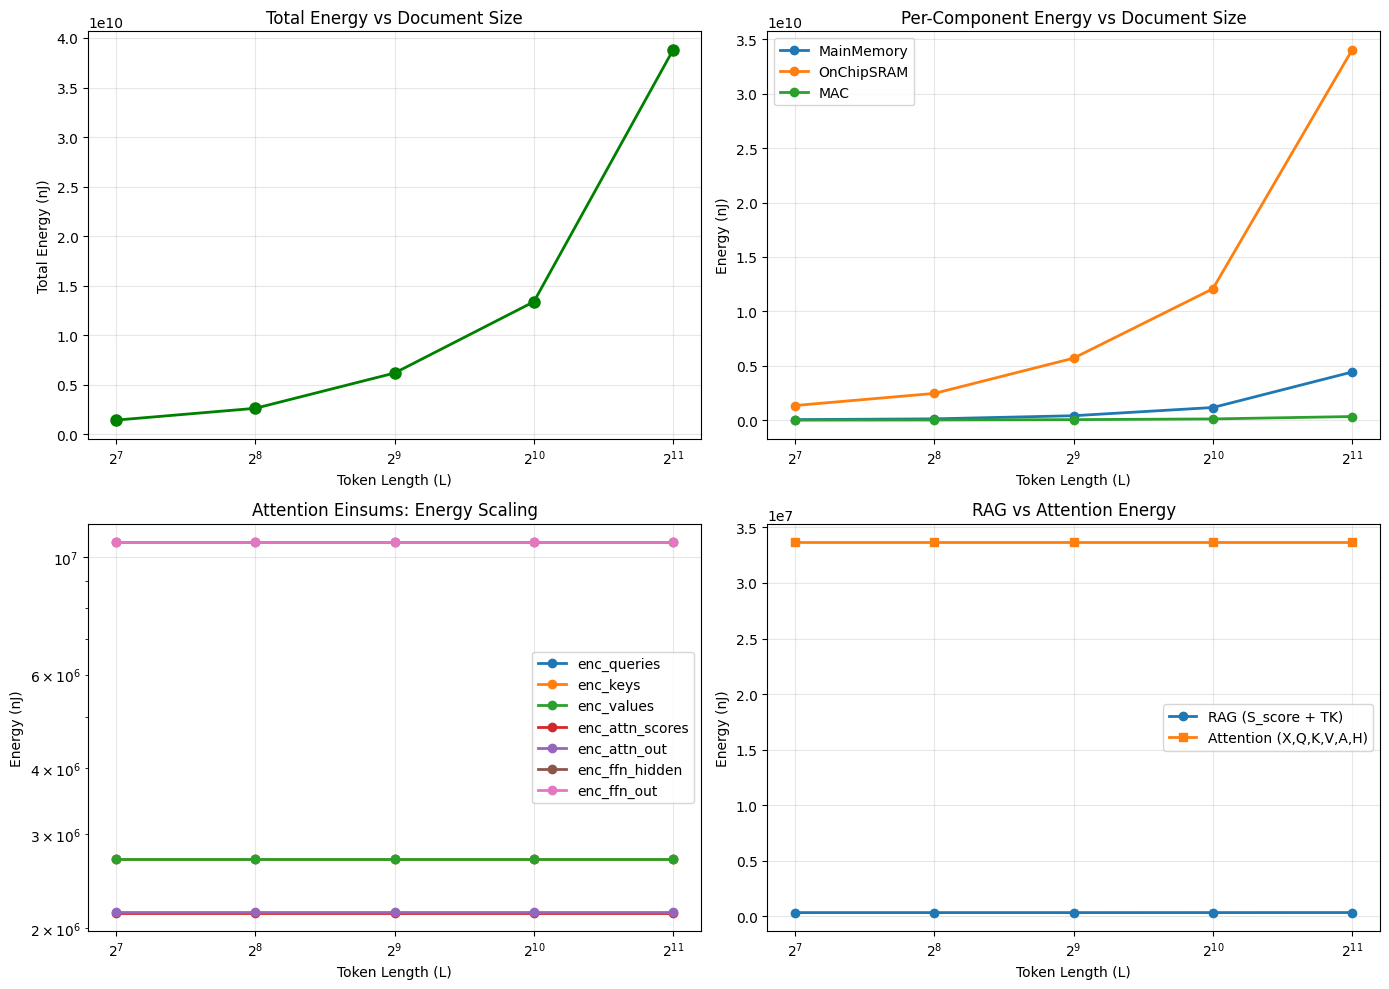

In [16]:
# Plot L sweep results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

l_list = list(sweep_l_results.keys())

# 1. Total energy vs L
ax1 = axes[0, 0]
total_energies = [sweep_l_results[t]['aggregated']['total_energy_J'] * 1e9 for t in l_list]
ax1.plot(l_list, total_energies, 'o-', linewidth=2, markersize=8, color='green')
ax1.set_xlabel('Token Length (L)')
ax1.set_ylabel('Total Energy (nJ)')
ax1.set_title('Total Energy vs Document Size')
ax1.set_xscale('log', base=2)
ax1.grid(True, alpha=0.3)

# 2. Per-component energy vs L
ax2 = axes[0, 1]
for comp in components:
    energies = [sweep_l_results[t]['aggregated']['per_component_energy_J'].get(comp, 0) * 1e9
                for t in l_list]
    ax2.plot(l_list, energies, 'o-', label=comp, linewidth=2, markersize=6)
ax2.set_xlabel('Token Length (L)')
ax2.set_ylabel('Energy (nJ)')
ax2.set_title('Per-Component Energy vs Document Size')
ax2.set_xscale('log', base=2)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Attention einsums (Q, K, V, A, H) scaling with L
ax3 = axes[1, 0]
attention_einsums = ['enc_queries', 'enc_keys', 'enc_values', 'enc_attn_scores', 'enc_attn_out', 'enc_ffn_hidden', 'enc_ffn_out']
for einsum_name in attention_einsums:
    energies = [sweep_l_results[t]['aggregated']['per_einsum_energy_J'].get(einsum_name, 0) * 1e9
                for t in l_list]
    ax3.plot(l_list, energies, 'o-', label=einsum_name, linewidth=2, markersize=6)
ax3.set_xlabel('Token Length (L)')
ax3.set_ylabel('Energy (nJ)')
ax3.set_title('Attention Einsums: Energy Scaling')
ax3.set_xscale('log', base=2)
ax3.set_yscale('log')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. RAG vs Attention energy comparison
ax4 = axes[1, 1]
rag_total = [sum(sweep_l_results[t]['aggregated']['per_einsum_energy_J'].get(e, 0)
                 for e in rag_einsums) * 1e9 for t in l_list]
attn_total = [sum(sweep_l_results[t]['aggregated']['per_einsum_energy_J'].get(e, 0)
                  for e in attention_einsums) * 1e9 for t in l_list]
ax4.plot(l_list, rag_total, 'o-', label='RAG (S_score + TK)', linewidth=2, markersize=6)
ax4.plot(l_list, attn_total, 's-', label='Attention (X,Q,K,V,A,H)', linewidth=2, markersize=6)
ax4.set_xlabel('Token Length (L)')
ax4.set_ylabel('Energy (nJ)')
ax4.set_title('RAG vs Attention Energy')
ax4.set_xscale('log', base=2)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 11: 2D Heatmap — N_DOCS × L

Comprehensive analysis of how both parameters interact.

In [17]:
# 2D sweep: N_DOCS × l
N_DOCS_VALUES = [3600, 7200, 1_000_000, 2_000_000, 5_000_000] # wide range for EdgeRAG
L_VALUES = [128, 256, 512, 1024, 2048]

sweep_2d_results = {}

print("Running 2D sweep (N_DOCS × l)...")
for n_docs in N_DOCS_VALUES:
    for l in L_VALUES:
        print(f"  N_DOCS={n_docs}, L={l}...", end=" ")

        params = {
            # 'VOCAB_SIZE': 32000,
            'N_DOCS': n_docs,
            'L': l,
            'K': 10,
        }

        results_sweep = run_rag_workload(params, arch_overrides)
        sweep_2d_results[(n_docs, l)] = {
            'results': results_sweep,
            'aggregated': aggregate_results(results_sweep),
        }
        print(f"done")

print("2D sweep complete.")

Running 2D sweep (N_DOCS × l)...
  N_DOCS=3600, L=128... done
  N_DOCS=3600, L=256... done
  N_DOCS=3600, L=512... done
  N_DOCS=3600, L=1024... done
  N_DOCS=3600, L=2048... done
  N_DOCS=7200, L=128... done
  N_DOCS=7200, L=256... done
  N_DOCS=7200, L=512... done
  N_DOCS=7200, L=1024... done
  N_DOCS=7200, L=2048... done
  N_DOCS=1000000, L=128... done
  N_DOCS=1000000, L=256... done
  N_DOCS=1000000, L=512... done
  N_DOCS=1000000, L=1024... done
  N_DOCS=1000000, L=2048... done
  N_DOCS=2000000, L=128... done
  N_DOCS=2000000, L=256... done
  N_DOCS=2000000, L=512... done
  N_DOCS=2000000, L=1024... done
  N_DOCS=2000000, L=2048... done
  N_DOCS=5000000, L=128... done
  N_DOCS=5000000, L=256... done
  N_DOCS=5000000, L=512... done
  N_DOCS=5000000, L=1024... done
  N_DOCS=5000000, L=2048... done
2D sweep complete.


## Step 12: Prefill vs Decode Stage Analysis

In LLMs, **prefill** processes the full input context (Q, K, V computation), while **decode** generates tokens one at a time. In RAG, we can categorize:

- **Prefill-like**: QKV projections, Attention
- **Retrieval**: Similarity search, document fetch
- **Decode** LLM output generation

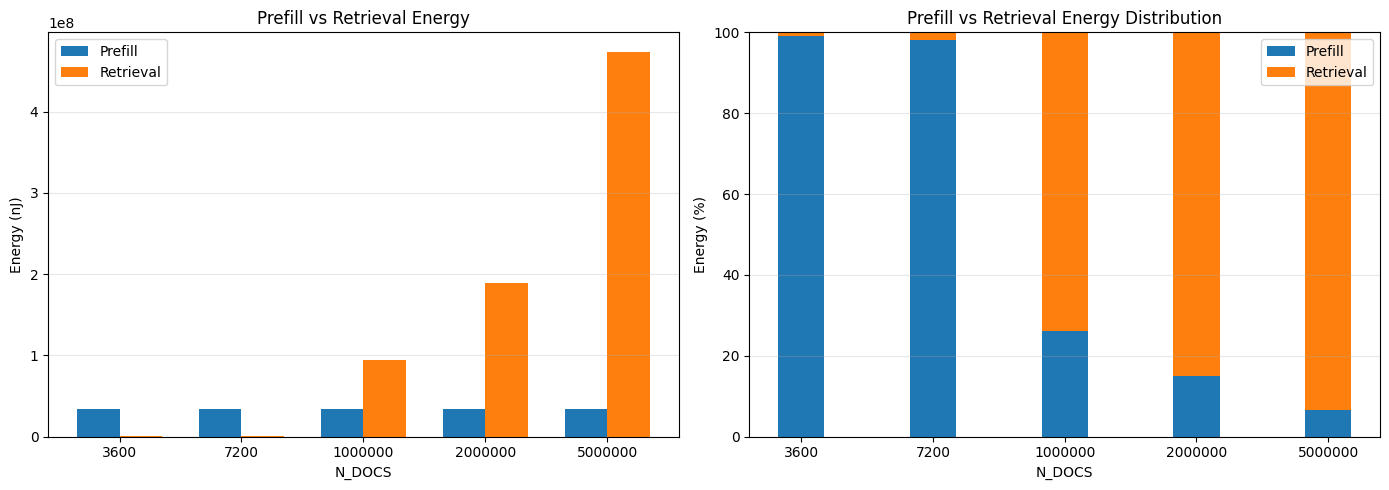


Prefill vs Retrieval Summary:
------------------------------------------------------------
N_DOCS     Prefill (nJ)    Retrieval (nJ)  Retrieval % 
------------------------------------------------------------
3600       33655789.61     342401.88       1.0         
7200       33655789.61     683507.60       2.0         
1000000    33655789.61     94757331.25     73.8        
2000000    33655789.61     189513409.83    84.9        
5000000    33655789.61     473781704.35    93.4        


In [18]:
# Categorize einsums into stages
PREFILL_EINSUMS = attention_einsums
RETRIEVAL_EINSUMS = rag_einsums
DECODE_EINSUMS = ['dec_queries', 'dec_keys', 'dec_values', 'dec_attn_scores', 'dec_attn_out', 'dec_attn_proj', 'dec_ffn_gate', 'dec_ffn_up', 'dec_ffn_swiglu', 'dec_ffn_out']

def categorize_energy(aggregated):
    """Split energy by stage."""
    prefill = sum(aggregated['per_einsum_energy_J'].get(e, 0) for e in PREFILL_EINSUMS)
    retrieval = sum(aggregated['per_einsum_energy_J'].get(e, 0) for e in RETRIEVAL_EINSUMS)
    return {'Prefill': prefill, 'Retrieval': retrieval}

# Analyze stages across N_DOCS sweep
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Absolute energy by stage
ax1 = axes[0]
prefill_energies = []
retrieval_energies = []
for n_docs in N_DOCS_VALUES:
    cat = categorize_energy(sweep_n_docs_results[n_docs]['aggregated'])
    prefill_energies.append(cat['Prefill'] * 1e9)
    retrieval_energies.append(cat['Retrieval'] * 1e9)

x = np.arange(len(N_DOCS_VALUES))
width = 0.35
ax1.bar(x - width/2, prefill_energies, width, label='Prefill')
ax1.bar(x + width/2, retrieval_energies, width, label='Retrieval')
ax1.set_xlabel('N_DOCS')
ax1.set_ylabel('Energy (nJ)')
ax1.set_title('Prefill vs Retrieval Energy')
ax1.set_xticks(x)
ax1.set_xticklabels(N_DOCS_VALUES)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Percentage breakdown
ax2 = axes[1]
prefill_pct = []
retrieval_pct = []
for n_docs in N_DOCS_VALUES:
    cat = categorize_energy(sweep_n_docs_results[n_docs]['aggregated'])
    total = cat['Prefill'] + cat['Retrieval']
    prefill_pct.append(100 * cat['Prefill'] / total if total > 0 else 0)
    retrieval_pct.append(100 * cat['Retrieval'] / total if total > 0 else 0)

ax2.bar(x, prefill_pct, width, label='Prefill')
ax2.bar(x, retrieval_pct, width, bottom=prefill_pct, label='Retrieval')
ax2.set_xlabel('N_DOCS')
ax2.set_ylabel('Energy (%)')
ax2.set_title('Prefill vs Retrieval Energy Distribution')
ax2.set_xticks(x)
ax2.set_xticklabels(N_DOCS_VALUES)
ax2.legend()
ax2.set_ylim(0, 100)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("\nPrefill vs Retrieval Summary:")
print("-" * 60)
print(f"{'N_DOCS':<10} {'Prefill (nJ)':<15} {'Retrieval (nJ)':<15} {'Retrieval %':<12}")
print("-" * 60)
for i, n_docs in enumerate(N_DOCS_VALUES):
    print(f"{n_docs:<10} {prefill_energies[i]:<15.2f} {retrieval_energies[i]:<15.2f} {retrieval_pct[i]:<12.1f}")

## Step 13: Summary Report — Bottleneck Analysis

In [19]:
print("=" * 80)
print("MILESTONE 2 SUMMARY: RAG Bottleneck Analysis")
print("=" * 80)

print("""
ARCHITECTURE: basic8 (TPUv4i-like with Disk)
  - Disk: Infinite, zero energy (offline embedding)
  - MainMemory (DRAM): 8 GB LPDDR5, 68 GB/s, 7.03 pJ/access
  - OnChipSRAM: 8 MB, 512/128 GB/s read/write
  - MAC: FP16, 0.084 pJ/op

WORKLOAD: RAG_LLM
  - Embed tokens → QKV → Attention → Similarity → Top-K → Generation
""")

print("\n" + "=" * 80)
print("KEY FINDINGS")
print("=" * 80)

# Use baseline results for analysis
agg = aggregate_results(results)
sorted_einsums = sorted(agg['per_einsum_energy_J'].items(), key=lambda x: x[1], reverse=True)
sorted_components = sorted(agg['per_component_energy_J'].items(), key=lambda x: x[1], reverse=True)

print(f"""
1. ARCHITECTURAL BOTTLENECK: {sorted_components[0][0]}
   - Accounts for {100*sorted_components[0][1]/agg['total_energy_J']:.1f}% of total energy

2. EINSUM BOTTLENECK: {sorted_einsums[0][0]}
   - Accounts for {100*sorted_einsums[0][1]/agg['total_energy_J']:.1f}% of total energy
""")

# Analyze bottleneck shifts from ACTUAL sweep data
print("=" * 80)
print("BOTTLENECK SHIFTS (derived from sweep data)")
print("=" * 80)

attention_einsums = ['enc_queries', 'enc_keys', 'enc_values', 'enc_attn_scores', 'enc_attn_out', 'enc_ffn_hidden', 'enc_ffn_out']
rag_einsums = ['doc_scores', 'topk_doc_ids', 'topk_tokens']


print("\n3. N_DOCS SWEEP ANALYSIS:")
print("-" * 60)
for n_docs in N_DOCS_VALUES:
    agg_n = sweep_n_docs_results[n_docs]['aggregated']

    # Top einsum
    top_einsum = max(agg_n['per_einsum_energy_J'].items(), key=lambda x: x[1])
    top_einsum_pct = 100 * top_einsum[1] / agg_n['total_energy_J']

    # Top component
    top_comp = max(agg_n['per_component_energy_J'].items(), key=lambda x: x[1])
    top_comp_pct = 100 * top_comp[1] / agg_n['total_energy_J']

    # Retrieval vs Prefill
    retrieval_e = sum(agg_n['per_einsum_energy_J'].get(e, 0) for e in rag_einsums)
    prefill_e = sum(agg_n['per_einsum_energy_J'].get(e, 0) for e in attention_einsums)
    retrieval_pct = 100 * retrieval_e / agg_n['total_energy_J']

    print(f"  N_DOCS={n_docs:>4}: Top einsum={top_einsum[0]:<8} ({top_einsum_pct:>5.1f}%), "
          f"Top component={top_comp[0]:<12} ({top_comp_pct:>5.1f}%), Retrieval={retrieval_pct:>5.1f}%")

print("\n4. L SWEEP ANALYSIS:")
print("-" * 60)
for l in L_VALUES:
    agg_t = sweep_l_results[l]['aggregated']

    # Top einsum
    top_einsum = max(agg_t['per_einsum_energy_J'].items(), key=lambda x: x[1])
    top_einsum_pct = 100 * top_einsum[1] / agg_t['total_energy_J']

    # A (attention) energy
    a_energy = agg_t['per_einsum_energy_J'].get('dec_attn_out', 0) * 1e9

    print(f"  l={l:>4}: Top einsum={top_einsum[0]:<8} ({top_einsum_pct:>5.1f}%), "
          f"A energy={a_energy:>10.2f} nJ")

# Check quadratic scaling of A
print("\n5. ATTENTION (dec_attn_out) SCALING CHECK:")
print("-" * 60)
a_energies = [sweep_l_results[t]['aggregated']['per_einsum_energy_J'].get('dec_attn_out', 0) for t in L_VALUES]
for i in range(1, len(L_VALUES)):
    t_ratio = L_VALUES[i] / L_VALUES[i-1]
    e_ratio = a_energies[i] / a_energies[i-1] if a_energies[i-1] > 0 else 0
    expected = t_ratio ** 2  # quadratic scaling
    print(f"  T: {L_VALUES[i-1]} → {L_VALUES[i]} (×{t_ratio:.1f}): "
          f"A energy ratio = {e_ratio:.2f}× (expected ×{expected:.1f} if quadratic)")

# Create a final summary DataFrame
print("\n" + "=" * 80)
print("DETAILED BREAKDOWN TABLE")
print("=" * 80)

summary_data = []
for name, energy in sorted_einsums:
    computes = agg['per_einsum_computes'][name]
    pj_per_compute = (energy / computes * 1e12) if computes > 0 else 0
    result = results[name]
    result.clear_zero_energies()
    top_component = max(result.per_component_energy.items(), key=lambda x: x[1])[0] if result.per_component_energy else 'N/A'
    summary_data.append({
        'Einsum': name,
        'Energy (nJ)': energy * 1e9,
        '% of Total': 100 * energy / agg['total_energy_J'],
        'Computes': computes,
        'pJ/compute': pj_per_compute,
        'Top Component': top_component,
    })

df = pd.DataFrame(summary_data)
print(df.to_string(index=False))

MILESTONE 2 SUMMARY: RAG Bottleneck Analysis

ARCHITECTURE: basic8 (TPUv4i-like with Disk)
  - Disk: Infinite, zero energy (offline embedding)
  - MainMemory (DRAM): 8 GB LPDDR5, 68 GB/s, 7.03 pJ/access
  - OnChipSRAM: 8 MB, 512/128 GB/s read/write
  - MAC: FP16, 0.084 pJ/op

WORKLOAD: RAG_LLM
  - Embed tokens → QKV → Attention → Similarity → Top-K → Generation


KEY FINDINGS

1. ARCHITECTURAL BOTTLENECK: OnChipSRAM
   - Accounts for 89.8% of total energy

2. EINSUM BOTTLENECK: dec_ffn_out
   - Accounts for 14.9% of total energy

BOTTLENECK SHIFTS (derived from sweep data)

3. N_DOCS SWEEP ANALYSIS:
------------------------------------------------------------
  N_DOCS=3600: Top einsum=dec_ffn_out ( 15.0%), Top component=OnChipSRAM   ( 92.3%), Retrieval=  0.0%
  N_DOCS=7200: Top einsum=dec_ffn_out ( 15.0%), Top component=OnChipSRAM   ( 92.3%), Retrieval=  0.0%
  N_DOCS=1000000: Top einsum=dec_ffn_out ( 14.8%), Top component=OnChipSRAM   ( 91.1%), Retrieval=  1.5%
  N_DOCS=2000000: Top e

## Step 14: Export Baseline for Experiment-2-Caching

Persists per-einsum energy and latency from the baseline run to `baseline_cache.pkl`.
`Experiment-2-Caching.ipynb` loads this file, drops the `doc_scores` (SIM) term, and
replaces it with the cache-simulator's hit/miss model. Re-run this cell whenever the
baseline `results` dict is regenerated.

In [ ]:
import pickle

baseline_energy_J = {}
baseline_latency_s = {}

for name, result in results.items():
    baseline_energy_J[name] = sum(result.per_component_energy.values())
    try:
        baseline_latency_s[name] = float(result._mappings.latency())
    except Exception as e:
        print(f'  warning: latency unavailable for {name}: {e}')
        baseline_latency_s[name] = 0.0

SIM_EINSUM = 'doc_scores'
assert SIM_EINSUM in baseline_energy_J, (
    f"sim_einsum '{SIM_EINSUM}' not found. Available einsums: {list(baseline_energy_J)}"
)

bl = {
    'baseline_energy_J':  baseline_energy_J,
    'baseline_latency_s': baseline_latency_s,
    'sim_einsum':         SIM_EINSUM,
    'rag_params':         rag_params,
    'arch_overrides':     arch_overrides,
}

OUT_PATH = '/home/workspace/workspace/baseline_cache.pkl'
with open(OUT_PATH, 'wb') as f:
    pickle.dump(bl, f)

total_E_nJ  = sum(baseline_energy_J.values())  * 1e9
total_L_us  = sum(baseline_latency_s.values()) * 1e6
sim_E_nJ    = baseline_energy_J[SIM_EINSUM]    * 1e9
sim_L_us    = baseline_latency_s[SIM_EINSUM]   * 1e6

print(f'Wrote {OUT_PATH}')
print(f'  einsums:        {len(baseline_energy_J)}')
print(f'  sim_einsum:     {SIM_EINSUM}  (E={sim_E_nJ:.2f} nJ, L={sim_L_us:.2f} us)')
print(f'  total energy:   {total_E_nJ:,.2f} nJ')
print(f'  total latency:  {total_L_us:,.2f} us')